In [2]:
import pysewer 
import networkx as nx 
import matplotlib.pyplot as plt
from pysewer.config.settings import load_config, view_default_settings, config_to_dataframe

from matplotlib.dates import DateFormatter

myfmt = DateFormatter('%m.%y')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial','Tahoma', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
plt.rcParams['font.size'] = 15
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 17
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['xtick.major.pad'] = 5  # distance to major tick label in points



In [3]:
# show the default congifuration
# here you can see that the input data is missing. You can either create a config file to add them or add them manually.
view_default_settings()

,Setting,Value
0,preprocessing_dem_file_path,None
1,preprocessing_roads_input_data,None
2,preprocessing_buildings_input_data,None
3,preprocessing_dx,10
4,preprocessing_pump_penalty,1000
5,preprocessing_max_connection_length,30
6,preprocessing_clustering,centers
7,preprocessing_connect_buildings,True
8,preprocessing_add_private_sewer,True
9,preprocessing_field_get_sinks,node_type


In [4]:
# load custom settings from the example settings file
custom_config = load_config("./test_data_settings.yaml")
df_config = config_to_dataframe(custom_config)
display(df_config)


,Setting,Value
0,preprocessing_dem_file_path,../tests/test_data/dem.tif
1,preprocessing_roads_input_data,../tests/test_data/roads_clipped.shp
2,preprocessing_buildings_input_data,../tests/test_data/buildings_clipped.shp
3,preprocessing_dx,10
4,preprocessing_pump_penalty,1000
5,preprocessing_max_connection_length,30
6,preprocessing_clustering,centers
7,preprocessing_connect_buildings,True
8,preprocessing_add_private_sewer,True
9,preprocessing_field_get_sinks,node_type


In [5]:
# Instantiate the model domain
test_model_domain = pysewer.ModelDomain(
    dem=custom_config.preprocessing.dem_file_path,
    buildings=custom_config.preprocessing.buildings_input_data,
    roads=custom_config.preprocessing.roads_input_data,
    clustering=custom_config.preprocessing.clustering,
)

/Users/despot/miniconda3/envs/pysewer/lib/python3.10/site-packages/geopandas/geodataframe.py:1321: UserWarning: Geometry column does not contain geometry.
  warnings.warn("Geometry column does not contain geometry.")


No nodata values found in the DEM.


In [6]:
test_model_domain.add_sink((691350, 2553250))

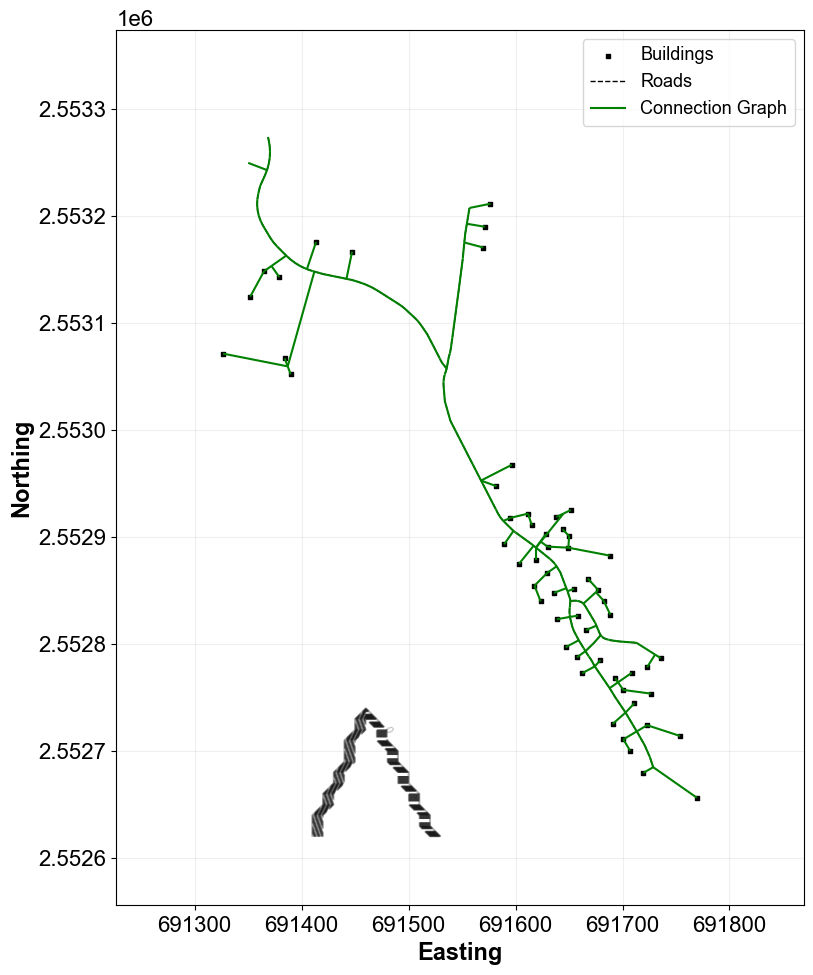

In [7]:
import earthpy.plot as ep
import earthpy.spatial as es
import rasterio
import numpy as np
from rasterio.plot import plotting_extent

hs_alt=30
hs_az=0

fig, ax = pysewer.plot_model_domain(
    test_model_domain,
    plot_connection_graph=custom_config.plotting.plot_connection_graph,
    hillshade=False,
    fig_size=(10, 10),
)

rasterio.plot.show(
            test_model_domain.dem.raster,
            contour=True,
            colors="black",
            ax=ax,
            levels=30,
            alpha=0.3,
        )
# rasterio.plot.show(test_model_domain.dem.raster, ax=ax, cmap="pink")
# # Create and plot the hillshade with earthpy
# elevation = test_model_domain.dem.raster.read(1)
# # Set masked values to np.nan
# elevation = elevation.astype(np.float32)
# elevation[elevation < 0] = 0

# print(f"Min: {np.min(elevation)}, Max: {np.max(elevation)}")
# hillshade = es.hillshade(elevation, altitude=hs_alt, azimuth=hs_az)

# ep.plot_bands(
#             hillshade,
#             ax=ax,
#             extent=plotting_extent(test_model_domain.dem.raster),
#             cbar=True,
#             title="Hillshade made from DTM",
#             cmap="pink",
#             alpha=0.8,
#             scale=True
# )
# ax.set_title("Topographic Map with Connection Graph")
ax.set_title("")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("../data/figures/test_dem_elevation.svg", transparent=True, bbox_inches="tight")


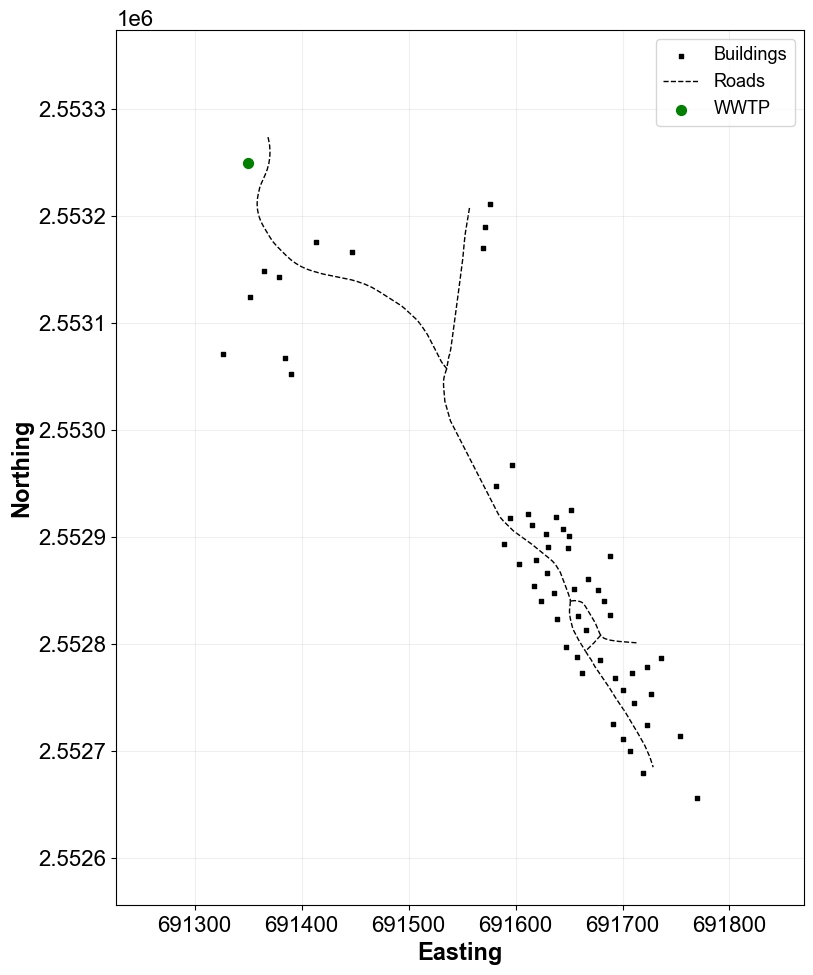

In [8]:
fig, ax = pysewer.plot_model_domain(
    test_model_domain, plot_sink=custom_config.plotting.plot_sink, fig_size=(10, 10)
)
ax.set_title("")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("../data/figures/test_infrastructure.svg", transparent=True, bbox_inches="tight")

In [9]:
# create the the graph conections
# this to be used for the routing algorithm
connection_graph = test_model_domain.generate_connection_graph()

200
98
Simplified graph: 200 to 97 nodes, 232 to 129 edges


In [10]:
test_model_domain.get_sinks()

[(691350.0, 2553250.0)]

In [11]:
layout = pysewer.rsph_tree(connection_graph, test_model_domain.get_sinks(), "building")

Number of weakly connected components: 1
Number of terminals (buildings) to process: 57
Number of nodes in final sewer graph: 97
Number of edges in final sewer graph: 95


In [12]:
test_model_domain.add_sink((691350, 2553250))

No pumping station in the sewer graph
Plotting sewer graph without pumping station


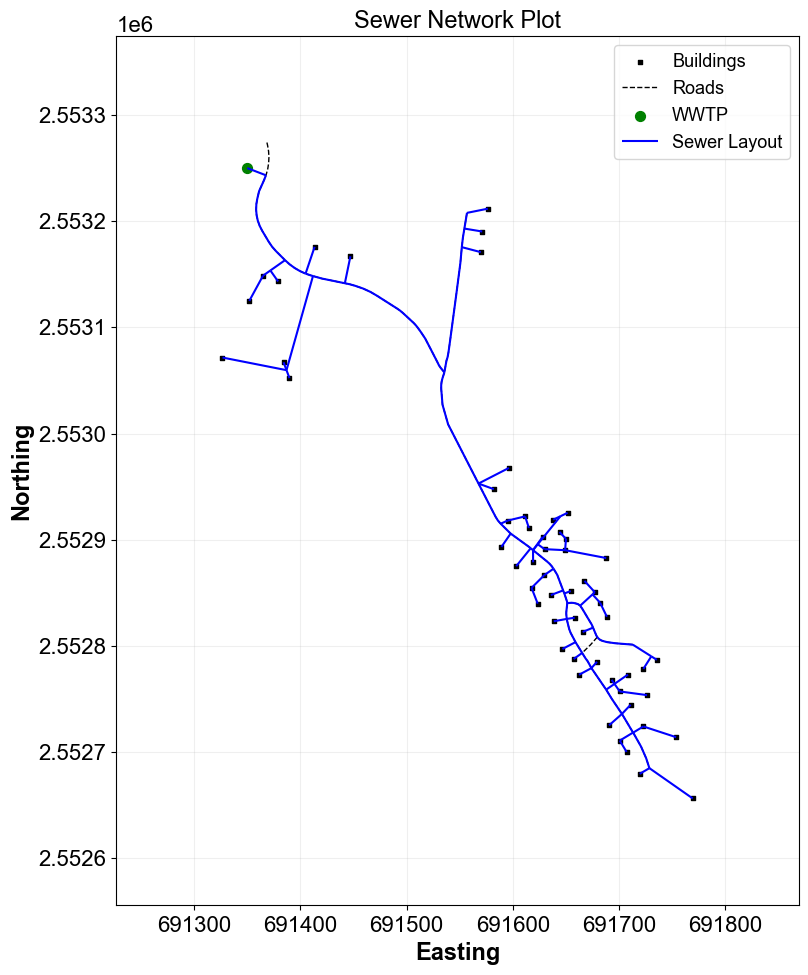

In [13]:
fig, ax = pysewer.plot_model_domain(
    test_model_domain, plot_sewer=True, sewer_graph=layout, plot_sink=True, fig_size=(10, 10)
)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("../data/figures/test_sewer_network.svg", transparent=True, bbox_inches="tight")
plt.show()

0


/Users/despot/miniconda3/envs/pysewer/lib/python3.10/site-packages/geopandas/plotting.py:678: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


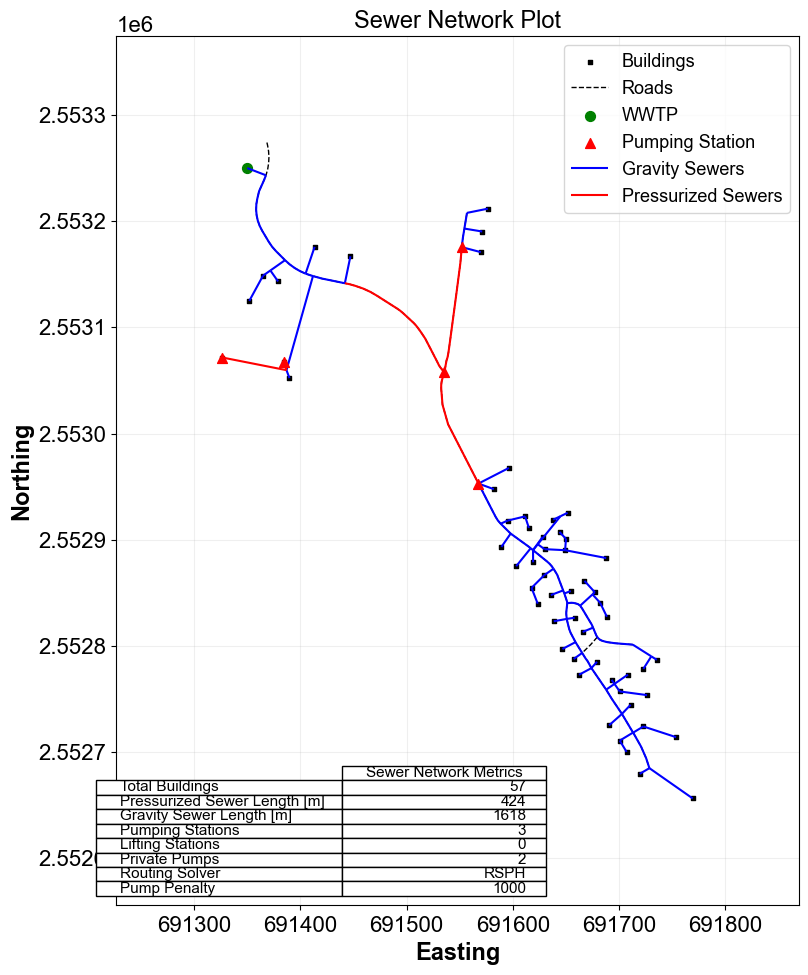

In [14]:
G = pysewer.estimate_peakflow(
    layout,
    inhabitants_dwelling=custom_config.optimization.inhabitants_dwelling,
    daily_wastewater_person=custom_config.optimization.daily_wastewater_person,
)
G = pysewer.calculate_hydraulic_parameters(
    layout,
    sinks=test_model_domain.get_sinks(),
    diameters=custom_config.optimization.diameters,
    pressurized_diameter=custom_config.optimization.pressurized_diameter,
    include_private_sewer=True,
    roughness=custom_config.optimization.roughness,
)
info = pysewer.get_sewer_info(G)
info["Routing Solver"] = "RSPH"
info["Pump Penalty"] = test_model_domain.pump_penalty
fig, ax = pysewer.plot_model_domain(
    test_model_domain, plot_sewer=True, sewer_graph=G, info_table=info, plot_sink=True, fig_size=(10, 10)
)

ax.set_title("Sewer Network Plot")
plt.legend(loc="upper right")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("../data/figures/test_optimized_sewer_network.svg", transparent=True, bbox_inches="tight")
plt.show()

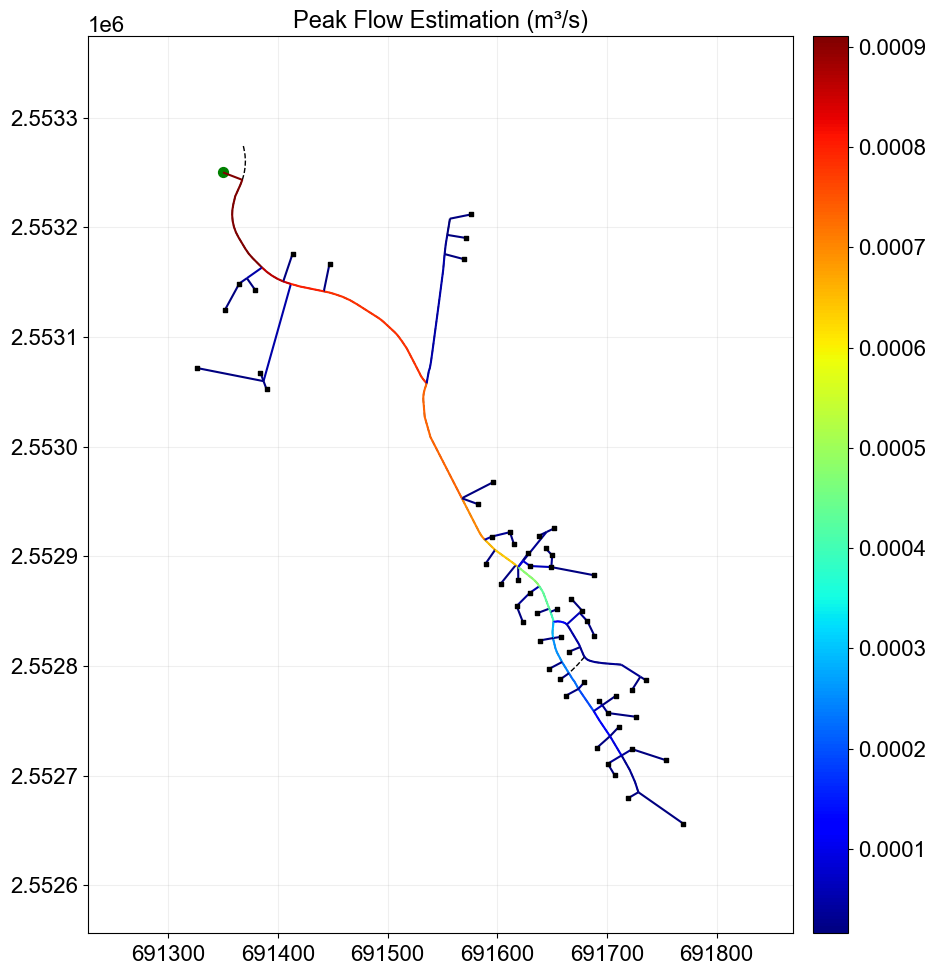

In [15]:
fig, ax  = pysewer.plot_sewer_attributes(
    test_model_domain, G, attribute="peak_flow", title="Peak Flow Estimation (m³/s)", fig_size=(10, 10)
)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("../data/figures/test_peak_flow_estimation.svg", transparent=True, bbox_inches="tight")
plt.show()

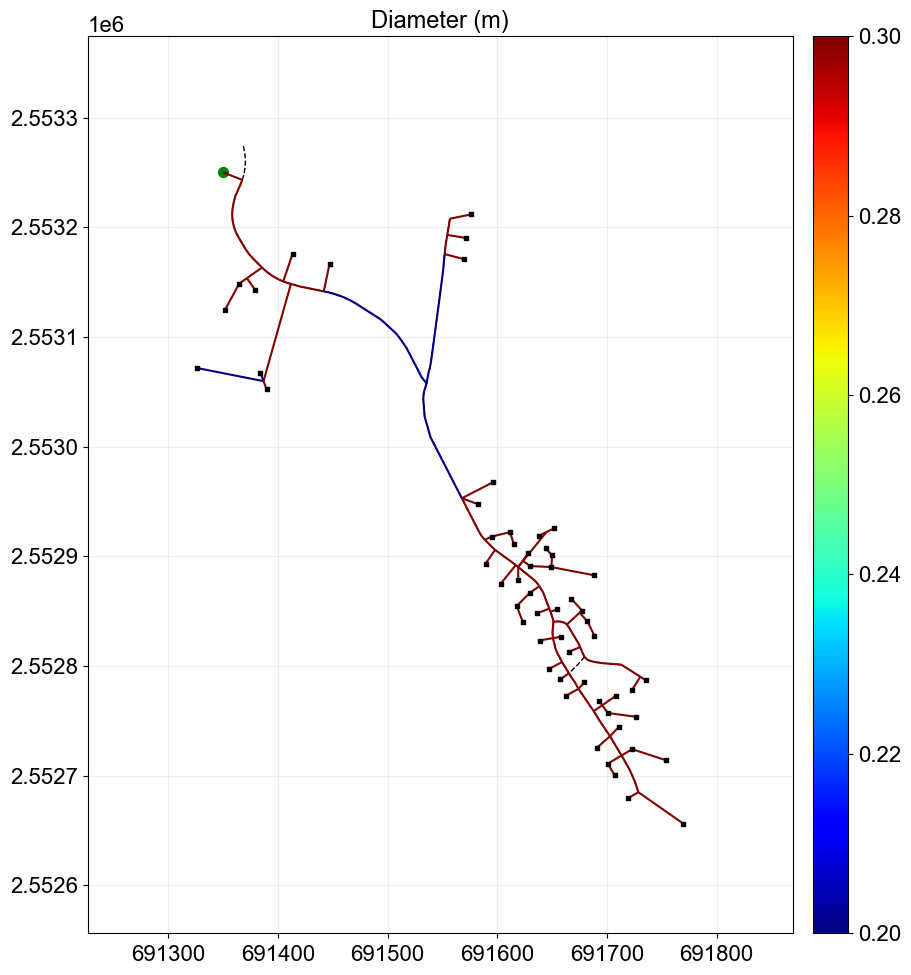

In [16]:
fig, ax = pysewer.plot_sewer_attributes(
    test_model_domain, G, attribute="diameter", title="Diameter (m)", fig_size=(10, 10)
)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("../data/figures/test_diameter.svg", transparent=True, bbox_inches="tight")
plt.show()

In [18]:
import matplotlib.animation as animation  # Add this import at the top
def create_sewer_layout_animation(model_domain, layout, output_path='sewer_network_animation.mp4'):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get all edges from the layout
    edges = list(layout.edges(data=True))
    
    # Get building coordinates for plotting - using get_gdf() to access the GeoDataFrame
    buildings_gdf = model_domain.buildings.get_gdf()
    building_coords = [(geom.x, geom.y) for geom in buildings_gdf.geometry]
    building_x, building_y = zip(*building_coords)
    
    # Get sink coordinates
    sink_coords = model_domain.get_sinks()
    sink_x = [coord[0] for coord in sink_coords]
    sink_y = [coord[1] for coord in sink_coords]
    
    def update(frame_num):
        ax.clear()
        
        # Plot buildings
        ax.scatter(building_x, building_y, color='black', s=10, label='Buildings')
        
        # Plot sinks (WWTP)
        if sink_coords:  # Only plot if there are sinks
            ax.scatter(sink_x, sink_y, color='red', s=50, marker='*', label='WWTP')
        
        # Plot edges up to current frame
        for edge in edges[:frame_num]:
            start_node = edge[0]
            end_node = edge[1]
            if 'pos' in layout.nodes[start_node] and 'pos' in layout.nodes[end_node]:
                start_x, start_y = layout.nodes[start_node]['pos']
                end_x, end_y = layout.nodes[end_node]['pos']
                ax.plot([start_x, end_x], [start_y, end_y], 'b-', linewidth=1)
            else:
                # If no position attribute, use node coordinates directly
                ax.plot([start_node[0], end_node[0]], [start_node[1], end_node[1]], 'b-', linewidth=1)
        
        # Set plot properties
        ax.set_xlabel('Eastings')
        ax.set_ylabel('Northings')
        ax.set_title(f'Sewer Network Generation (Step {frame_num}/{len(edges)})')
        ax.grid(alpha=0.3)
        ax.legend()
        
        # # Set axis limits based on your bounding box
        # ax.set_xlim(bounding_box['left'], bounding_box['right'])
        # ax.set_ylim(bounding_box['bottom'], bounding_box['top'])
    
    # Create animation
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(edges) + 1,
        interval=200,  # 200ms between frames
        repeat=False
    )
    
    # Save animation
    if output_path.endswith('.gif'):
        anim.save(output_path, writer='pillow', fps=5)
    else:
        anim.save(output_path, writer='ffmpeg', fps=5)
    plt.close()

# Create the animation
create_sewer_layout_animation(test_model_domain, layout, 'sewer_network_animation.gif')

In [19]:
import matplotlib.animation as animation

def create_sewer_layout_animation(model_domain, layout, output_path='sewer_network_animation.mp4'):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get building coordinates for plotting
    buildings_gdf = model_domain.buildings.get_gdf()
    building_coords = [(geom.x, geom.y) for geom in buildings_gdf.geometry]
    building_x, building_y = zip(*building_coords)
    
    # Get sink coordinates (WWTP)
    sink_coords = model_domain.get_sinks()
    
    # Get the edges in the correct order (from sink outward)
    edges_with_data = list(layout.edges(data=True))
    
    # Sort edges based on distance from sink
    def get_edge_distance_from_sink(edge):
        start_node, end_node = edge[0], edge[1]
        min_dist = float('inf')
        for sink in sink_coords:
            dist = min(
                ((start_node[0] - sink[0])**2 + (start_node[1] - sink[1])**2)**0.5,
                ((end_node[0] - sink[0])**2 + (end_node[1] - sink[1])**2)**0.5
            )
            min_dist = min(min_dist, dist)
        return min_dist
    
    # Sort edges by distance from sink
    sorted_edges = sorted(edges_with_data, key=get_edge_distance_from_sink)
    
    def update(frame_num):
        ax.clear()
        
        # Plot buildings
        ax.scatter(building_x, building_y, color='black', s=10, label='Buildings', alpha=0.5)
        
        # Plot sinks (WWTP)
        if sink_coords:
            sink_x = [coord[0] for coord in sink_coords]
            sink_y = [coord[1] for coord in sink_coords]
            ax.scatter(sink_x, sink_y, color='red', s=100, marker='*', label='WWTP')
        
        # Plot edges up to current frame
        connected_nodes = set()
        if sink_coords:
            connected_nodes.update(sink_coords)
            
        for edge in sorted_edges[:frame_num]:
            start_node = edge[0]
            end_node = edge[1]
            
            # Plot the edge
            ax.plot([start_node[0], end_node[0]], 
                   [start_node[1], end_node[1]], 
                   'b-', linewidth=1, alpha=0.7)
            
            # Highlight connected nodes
            connected_nodes.add(start_node)
            connected_nodes.add(end_node)
            
        # Highlight connected nodes
        if connected_nodes:
            connected_x = [node[0] for node in connected_nodes if node not in sink_coords]
            connected_y = [node[1] for node in connected_nodes if node not in sink_coords]
            if connected_x:  # Only plot if there are connected nodes
                ax.scatter(connected_x, connected_y, color='blue', s=30, 
                          label='Connected Nodes', zorder=5)
        
        # Set plot properties
        ax.set_xlabel('Eastings')
        ax.set_ylabel('Northings')
        ax.set_title(f'Sewer Network Generation\n(Step {frame_num}/{len(sorted_edges)})')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # Set axis limits based on buildings extent with some padding
        bounds = buildings_gdf.total_bounds
        padding = (bounds[2] - bounds[0]) * 0.05  # 5% padding
        ax.set_xlim(bounds[0] - padding, bounds[2] + padding)
        ax.set_ylim(bounds[1] - padding, bounds[3] + padding)
    
    # Create animation
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(sorted_edges) + 1,
        interval=200,  # 200ms between frames
        repeat=False
    )
    
    # Save animation
    if output_path.endswith('.gif'):
        anim.save(output_path, writer='pillow', fps=5)
    else:
        anim.save(output_path, writer='ffmpeg', fps=5)
    plt.close()

# Create the animation
create_sewer_layout_animation(test_model_domain, layout, 'sewer_network_animation.gif')

In [21]:
import matplotlib.animation as animation

def create_sewer_layout_animation(model_domain, layout, output_path='sewer_network_animation.mp4'):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get all edges from the layout
    edges = list(layout.edges(data=True))
    
    # Get building coordinates for plotting - using get_gdf() to access the GeoDataFrame
    buildings_gdf = model_domain.buildings.get_gdf()
    building_coords = [(geom.x, geom.y) for geom in buildings_gdf.geometry]
    building_x, building_y = zip(*building_coords)
    
    # Get sink coordinates
    sink_coords = model_domain.get_sinks()
    
    def update(frame_num):
        ax.clear()
        
        # Plot buildings
        ax.scatter(building_x, building_y, color='black', s=10, label='Buildings')
        
        # Plot sinks (WWTP)
        if sink_coords:  # Only plot if there are sinks
            ax.scatter([coord[0] for coord in sink_coords], 
                      [coord[1] for coord in sink_coords], 
                      color='red', s=100, marker='*', label='WWTP')
        
        # Plot edges up to current frame
        connected_nodes = set()
        for edge in edges[:frame_num]:
            start_node = edge[0]
            end_node = edge[1]
            
            # Plot the edge
            ax.plot([start_node[0], end_node[0]], 
                   [start_node[1], end_node[1]], 
                   'b-', linewidth=1)
            
            # Add nodes to connected set
            connected_nodes.add(start_node)
            connected_nodes.add(end_node)
        
        # Plot connected nodes
        if connected_nodes:
            connected_x = [node[0] for node in connected_nodes if node not in sink_coords]
            connected_y = [node[1] for node in connected_nodes if node not in sink_coords]
            if connected_x:  # Only plot if there are connected nodes
                ax.scatter(connected_x, connected_y, color='blue', s=30, 
                          label='Connected Nodes', zorder=5)
        
        # Set plot properties
        ax.set_xlabel('Eastings')
        ax.set_ylabel('Northings')
        ax.set_title(f'Sewer Network Generation\n(Step {frame_num}/{len(edges)})')
        ax.grid(alpha=0.2)
        ax.legend()
        
        # Set axis limits based on all points (including sink)
        all_x = building_x + tuple(coord[0] for coord in sink_coords)
        all_y = building_y + tuple(coord[1] for coord in sink_coords)
        
        # Calculate bounds with padding
        x_min, x_max = min(all_x), max(all_x)
        y_min, y_max = min(all_y), max(all_y)
        padding_x = (x_max - x_min) * 0.05
        padding_y = (y_max - y_min) * 0.05
        
        ax.set_xlim(x_min - padding_x, x_max + padding_x)
        ax.set_ylim(y_min - padding_y, y_max + padding_y)
    
    # Create animation
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(edges) + 1,
        interval=200,  # 200ms between frames
        repeat=False
    )
    
    # Save animation
    if output_path.endswith('.gif'):
        anim.save(output_path, writer='pillow', fps=5)
    else:
        anim.save(output_path, writer='ffmpeg', fps=5)
    plt.close()

# Create the animation using the final layout after hydraulic calculations
create_sewer_layout_animation(test_model_domain, G, 'sewer_network_animation.gif')

In [22]:
import matplotlib.animation as animation
import networkx as nx

def create_sewer_layout_animation(model_domain, layout, output_path='sewer_network_animation.mp4'):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get building coordinates for plotting
    buildings_gdf = model_domain.buildings.get_gdf()
    building_coords = [(geom.x, geom.y) for geom in buildings_gdf.geometry]
    building_x, building_y = zip(*building_coords)
    
    # Get sink coordinates
    sink_coords = model_domain.get_sinks()
    sink = sink_coords[0] if sink_coords else None
    
    # Get edges and sort them to start from sink
    edges = list(layout.edges(data=True))
    
    # Create a helper function to sort edges based on distance from sink
    def sort_edges_from_sink(edges, sink):
        # Create a graph to help with sorting
        G_temp = nx.Graph()
        G_temp.add_edges_from((e[0], e[1]) for e in edges)
        
        # Initialize sorted edges and visited nodes
        sorted_edges = []
        visited_nodes = {sink}
        frontier = {sink}
        
        # While we haven't processed all edges
        while len(sorted_edges) < len(edges):
            new_frontier = set()
            # Find all edges connected to current frontier
            for edge in edges:
                start, end = edge[0], edge[1]
                if start in frontier and end not in visited_nodes:
                    sorted_edges.append(edge)
                    visited_nodes.add(end)
                    new_frontier.add(end)
                elif end in frontier and start not in visited_nodes:
                    sorted_edges.append(edge)
                    visited_nodes.add(start)
                    new_frontier.add(start)
            frontier = new_frontier
            if not frontier:  # If no new nodes found, add remaining edges
                remaining_edges = [e for e in edges if e not in sorted_edges]
                sorted_edges.extend(remaining_edges)
                break
                
        return sorted_edges
    
    # Sort edges starting from sink
    sorted_edges = sort_edges_from_sink(edges, sink)
    
    def update(frame_num):
        ax.clear()
        
        # Plot buildings
        ax.scatter(building_x, building_y, color='black', s=10, label='Buildings', alpha=0.5)
        
        # Plot sink (WWTP)
        if sink:
            ax.scatter([sink[0]], [sink[1]], color='red', s=200, marker='*', 
                      label='WWTP', zorder=10)
        
        # Plot edges up to current frame
        connected_nodes = {sink} if sink else set()
        for edge in sorted_edges[:frame_num]:
            start_node = edge[0]
            end_node = edge[1]
            
            # Plot the edge
            ax.plot([start_node[0], end_node[0]], 
                   [start_node[1], end_node[1]], 
                   'b-', linewidth=1, alpha=0.7)
            
            # Add nodes to connected set
            connected_nodes.add(start_node)
            connected_nodes.add(end_node)
        
        # Plot connected nodes
        if connected_nodes:
            connected_x = [node[0] for node in connected_nodes if node != sink]
            connected_y = [node[1] for node in connected_nodes if node != sink]
            if connected_x:  # Only plot if there are connected nodes
                ax.scatter(connected_x, connected_y, color='blue', s=30, 
                          label='Connected Nodes', zorder=5)
        
        # Set plot properties
        ax.set_xlabel('Eastings')
        ax.set_ylabel('Northings')
        ax.set_title(f'Sewer Network Generation\n(Step {frame_num}/{len(sorted_edges)})')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # Set axis limits based on all points (including sink)
        all_x = building_x + (sink[0],) if sink else building_x
        all_y = building_y + (sink[1],) if sink else building_y
        
        # Calculate bounds with padding
        x_min, x_max = min(all_x), max(all_x)
        y_min, y_max = min(all_y), max(all_y)
        padding_x = (x_max - x_min) * 0.05
        padding_y = (y_max - y_min) * 0.05
        
        ax.set_xlim(x_min - padding_x, x_max + padding_x)
        ax.set_ylim(y_min - padding_y, y_max + padding_y)
    
    # Create animation
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(sorted_edges) + 1,
        interval=200,  # 200ms between frames
        repeat=False
    )
    
    # Save animation
    if output_path.endswith('.gif'):
        anim.save(output_path, writer='pillow', fps=5)
    else:
        anim.save(output_path, writer='ffmpeg', fps=5)
    plt.close()

# Create the animation using the final layout
create_sewer_layout_animation(test_model_domain, G, 'sewer_network_animation1.gif')

In [23]:
import matplotlib.animation as animation
import networkx as nx
import rasterio.plot
import earthpy.plot as ep
import earthpy.spatial as es
import numpy as np
from rasterio.plot import plotting_extent

def create_sewer_layout_animation(model_domain, layout, output_path='sewer_network_animation.mp4'):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get building coordinates for plotting
    buildings_gdf = model_domain.buildings.get_gdf()
    building_coords = [(geom.x, geom.y) for geom in buildings_gdf.geometry]
    building_x, building_y = zip(*building_coords)
    
    # Get sink coordinates
    sink_coords = model_domain.get_sinks()
    sink = sink_coords[0] if sink_coords else None
    
    # Get edges and sort them to start from sink
    edges = list(layout.edges(data=True))
    
    # Create a helper function to sort edges based on distance from sink
    def sort_edges_from_sink(edges, sink):
        G_temp = nx.Graph()
        G_temp.add_edges_from((e[0], e[1]) for e in edges)
        sorted_edges = []
        visited_nodes = {sink}
        frontier = {sink}
        
        while len(sorted_edges) < len(edges):
            new_frontier = set()
            for edge in edges:
                start, end = edge[0], edge[1]
                if start in frontier and end not in visited_nodes:
                    sorted_edges.append(edge)
                    visited_nodes.add(end)
                    new_frontier.add(end)
                elif end in frontier and start not in visited_nodes:
                    sorted_edges.append(edge)
                    visited_nodes.add(start)
                    new_frontier.add(start)
            frontier = new_frontier
            if not frontier:
                remaining_edges = [e for e in edges if e not in sorted_edges]
                sorted_edges.extend(remaining_edges)
                break
        return sorted_edges
    
    # Sort edges starting from sink
    sorted_edges = sort_edges_from_sink(edges, sink)
    
    def update(frame_num):
        ax.clear()
        
        # Plot DEM and hillshade
        rasterio.plot.show(
            model_domain.dem.raster,
            contour=True,
            colors="grey",
            ax=ax,
            levels=30,
            alpha=0.5,
        )
        rasterio.plot.show(model_domain.dem.raster, ax=ax, cmap="Greys_r")
        
        # Create and plot hillshade
        elevation = model_domain.dem.raster.read(1)
        elevation = elevation.astype(float)
        elevation[elevation < 0] = np.nan
        hillshade = es.hillshade(elevation, altitude=30, azimuth=0)
        
        ep.plot_bands(
            hillshade,
            ax=ax,
            extent=plotting_extent(model_domain.dem.raster),
            cbar=False,
            title="",
            cmap="Greys_r",
            alpha=0.8,
        )
        
        # Plot roads
        model_domain.roads.gdf.plot(
            ax=ax, 
            label="Roads", 
            linewidth=1, 
            color="k", 
            zorder=1, 
            linestyle="dashed"
        )
        
        # Plot buildings
        ax.scatter(building_x, building_y, color='black', s=10, 
                  label='Buildings', alpha=0.5, zorder=4)
        
        # Plot sink (WWTP)
        if sink:
            ax.scatter([sink[0]], [sink[1]], color='red', s=200, marker='*', 
                      label='WWTP', zorder=10)
        
        # Plot edges up to current frame
        connected_nodes = {sink} if sink else set()
        for edge in sorted_edges[:frame_num]:
            start_node = edge[0]
            end_node = edge[1]
            
            # Plot the edge
            ax.plot([start_node[0], end_node[0]], 
                   [start_node[1], end_node[1]], 
                   'b-', linewidth=1, alpha=0.7, zorder=5)
            
            # Add nodes to connected set
            connected_nodes.add(start_node)
            connected_nodes.add(end_node)
        
        # Plot connected nodes
        if connected_nodes:
            connected_x = [node[0] for node in connected_nodes if node != sink]
            connected_y = [node[1] for node in connected_nodes if node != sink]
            if connected_x:
                ax.scatter(connected_x, connected_y, color='blue', s=30, 
                          label='Connected Nodes', zorder=6)
        
        # Set plot properties
        ax.set_xlabel('Eastings')
        ax.set_ylabel('Northings')
        ax.set_title(f'Sewer Network Generation\n(Step {frame_num}/{len(sorted_edges)})')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # Set axis limits based on all points (including sink)
        all_x = building_x + (sink[0],) if sink else building_x
        all_y = building_y + (sink[1],) if sink else building_y
        
        # Calculate bounds with padding
        x_min, x_max = min(all_x), max(all_x)
        y_min, y_max = min(all_y), max(all_y)
        padding_x = (x_max - x_min) * 0.05
        padding_y = (y_max - y_min) * 0.05
        
        ax.set_xlim(x_min - padding_x, x_max + padding_x)
        ax.set_ylim(y_min - padding_y, y_max + padding_y)
    
    # Create animation
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(sorted_edges) + 1,
        interval=200,
        repeat=False
    )
    
    # Save animation
    if output_path.endswith('.gif'):
        anim.save(output_path, writer='pillow', fps=5)
    else:
        anim.save(output_path, writer='ffmpeg', fps=5)
    plt.close()

# Create the animation using the final layout
create_sewer_layout_animation(test_model_domain, G, 'sewer_network_animation.gif')

In [29]:
import matplotlib.animation as animation
import networkx as nx
import rasterio.plot
import numpy as np

def create_sewer_layout_animation(model_domain, layout, output_path='sewer_network_animation.mp4'):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get building coordinates for plotting
    buildings_gdf = model_domain.buildings.get_gdf()
    building_coords = [(geom.x, geom.y) for geom in buildings_gdf.geometry]
    building_x, building_y = zip(*building_coords)
    
    # Get sink coordinates
    sink_coords = model_domain.get_sinks()
    sink = sink_coords[0] if sink_coords else None
    
    # Get edges and sort them to start from sink
    edges = list(layout.edges(data=True))
    
    def sort_edges_from_sink(edges, sink):
        G_temp = nx.Graph()
        G_temp.add_edges_from((e[0], e[1]) for e in edges)
        
        # Use actual paths from the layout
        sorted_edges = []
        visited_nodes = {sink}
        frontier = {sink}
        
        while len(sorted_edges) < len(edges):
            new_frontier = set()
            current_edges = []
            
            # Find all edges connected to current frontier
            for edge in edges:
                start, end = edge[0], edge[1]
                if start in frontier and end not in visited_nodes:
                    current_edges.append(edge)
                    visited_nodes.add(end)
                    new_frontier.add(end)
                elif end in frontier and start not in visited_nodes:
                    current_edges.append(edge)
                    visited_nodes.add(start)
                    new_frontier.add(start)
            
            # Sort current edges by their actual path length
            current_edges.sort(key=lambda e: layout.edges[e[0], e[1]].get('length', 0))
            sorted_edges.extend(current_edges)
            
            frontier = new_frontier
            if not frontier:
                remaining_edges = [e for e in edges if e not in sorted_edges]
                sorted_edges.extend(remaining_edges)
                break
                
        return sorted_edges
    
    # Sort edges starting from sink
    sorted_edges = sort_edges_from_sink(edges, sink)
    
    def update(frame_num):
        ax.clear()
        
        # Plot only contour lines from DEM
        rasterio.plot.show(
            model_domain.dem.raster,
            contour=True,
            colors="black",
            ax=ax,
            levels=30,
            alpha=0.3,
        )
        
        # Plot roads
        model_domain.roads.gdf.plot(
            ax=ax, 
            label="Roads", 
            linewidth=1, 
            color="gray", 
            zorder=2, 
            linestyle="dashed"
        )
        
        # Plot buildings
        ax.scatter(building_x, building_y, color='black', s=10, 
                  label='Buildings', alpha=0.7, zorder=4)
        
        # Plot sink (WWTP)
        if sink:
            ax.scatter([sink[0]], [sink[1]], color='red', s=200, marker='*', 
                      label='WWTP', zorder=10)
        
        # Plot edges up to current frame
        connected_nodes = {sink} if sink else set()
        for edge in sorted_edges[:frame_num]:
            start_node, end_node = edge[0], edge[1]
            
            # Get the actual path geometry if it exists
            if 'geometry' in layout.edges[start_node, end_node]:
                geom = layout.edges[start_node, end_node]['geometry']
                xs, ys = geom.xy
                ax.plot(xs, ys, 'b-', linewidth=1.5, alpha=0.7, zorder=5)
            else:
                # Fallback to direct connection
                ax.plot([start_node[0], end_node[0]], 
                       [start_node[1], end_node[1]], 
                       'b-', linewidth=1.5, alpha=0.7, zorder=5)
            
            # Add nodes to connected set
            connected_nodes.add(start_node)
            connected_nodes.add(end_node)
        
        # Plot connected nodes
        if connected_nodes:
            connected_x = [node[0] for node in connected_nodes if node != sink]
            connected_y = [node[1] for node in connected_nodes if node != sink]
            if connected_x:
                ax.scatter(connected_x, connected_y, color='blue', s=30, 
                          label='Connected Nodes', zorder=6)
        
        # Set plot properties
        ax.set_xlabel('Eastings')
        ax.set_ylabel('Northings')
        ax.set_title(f'Sewer Network Generation\n(Step {frame_num}/{len(sorted_edges)})')
        ax.grid(False)
        ax.legend()
        
        # Set axis limits based on all points
        all_x = building_x + (sink[0],) if sink else building_x
        all_y = building_y + (sink[1],) if sink else building_y
        
        # Calculate bounds with padding
        x_min, x_max = min(all_x), max(all_x)
        y_min, y_max = min(all_y), max(all_y)
        padding_x = (x_max - x_min) * 0.05
        padding_y = (y_max - y_min) * 0.05
        
        ax.set_xlim(x_min - padding_x, x_max + padding_x)
        ax.set_ylim(y_min - padding_y, y_max + padding_y)
    
    # Create animation
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(sorted_edges) + 1,
        interval=200,
        repeat=False
    )
    
    # Save animation
    if output_path.endswith('.gif'):
        anim.save(output_path, writer='pillow', fps=5)
    else:
        anim.save(output_path, writer='ffmpeg', fps=5)
    plt.close()

# Create the animation using the final layout
create_sewer_layout_animation(test_model_domain, G, 'sewer_network_animation_ok.gif')

NameError: name 'sorted_edges' is not defined

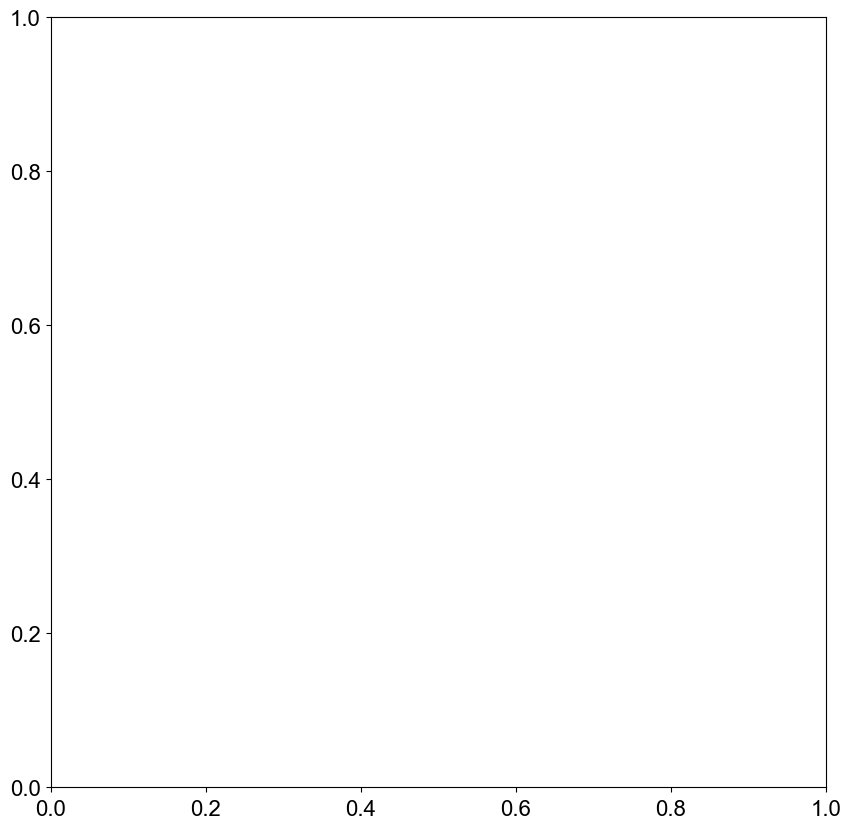

In [30]:
def create_sewer_layout_animation(
    model_domain, 
    layout, 
    output_path='sewer_network_animation.mp4',
    show_elevation=True,
    elevation_type='contour',  # 'contour' or 'dem'
    contour_color='black',
    contour_alpha=0.3,
    fps=5
):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # ... (keep existing initialization code) ...
    
    def update(frame_num):
        ax.clear()
        
        # Plot elevation if requested
        if show_elevation:
            if elevation_type == 'contour':
                rasterio.plot.show(
                    model_domain.dem.raster,
                    contour=True,
                    colors=contour_color,
                    ax=ax,
                    levels=30,
                    alpha=contour_alpha,
                )
            elif elevation_type == 'dem':
                # Plot DEM and hillshade
                rasterio.plot.show(
                    model_domain.dem.raster,
                    contour=True,
                    colors="grey",
                    ax=ax,
                    levels=30,
                    alpha=0.5,
                )
                rasterio.plot.show(model_domain.dem.raster, ax=ax, cmap="Greys_r")
        
        # Rest of your existing update function remains the same
        # Plot roads
        model_domain.roads.gdf.plot(
            ax=ax, 
            label="Roads", 
            linewidth=1, 
            color="gray", 
            zorder=2, 
            linestyle="dashed"
        )
        
        # ... (keep rest of the plotting code) ...
    
    # Create animation
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(sorted_edges) + 1,
        interval=200,
        repeat=False
    )
    
    # Save animation
    if output_path.endswith('.gif'):
        anim.save(output_path, writer='pillow', fps=fps)
    else:
        anim.save(output_path, writer='ffmpeg', fps=fps)
    plt.close()

# Example usage:
# Default with contour lines
create_sewer_layout_animation(test_model_domain, G, 'sewer_network_animation1.gif')

# Without elevation
create_sewer_layout_animation(
    test_model_domain, 
    G, 
    'sewer_network_animation2.gif', 
    show_elevation=False
)

# With DEM background
create_sewer_layout_animation(
    test_model_domain, 
    G, 
    'sewer_network_animation3.gif', 
    elevation_type='dem'
)

# With custom contour appearance
create_sewer_layout_animation(
    test_model_domain, 
    G, 
    'sewer_network_animation4.gif', 
    contour_color='gray', 
    contour_alpha=0.5
)

In [31]:
def create_sewer_layout_animation(
    model_domain, 
    layout, 
    output_path='sewer_network_animation.mp4',
    show_elevation=True,
    elevation_type='contour',  # 'contour' or 'dem'
    contour_color='black',
    contour_alpha=0.3,
    fps=5
):
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get building coordinates for plotting
    buildings_gdf = model_domain.buildings.get_gdf()
    building_coords = [(geom.x, geom.y) for geom in buildings_gdf.geometry]
    building_x, building_y = zip(*building_coords)
    
    # Get sink coordinates
    sink_coords = model_domain.get_sinks()
    sink = sink_coords[0] if sink_coords else None
    
    # Get edges and sort them to start from sink
    edges = list(layout.edges(data=True))
    
    def sort_edges_from_sink(edges, sink):
        G_temp = nx.Graph()
        G_temp.add_edges_from((e[0], e[1]) for e in edges)
        
        # Use actual paths from the layout
        sorted_edges = []
        visited_nodes = {sink}
        frontier = {sink}
        
        while len(sorted_edges) < len(edges):
            new_frontier = set()
            current_edges = []
            
            # Find all edges connected to current frontier
            for edge in edges:
                start, end = edge[0], edge[1]
                if start in frontier and end not in visited_nodes:
                    current_edges.append(edge)
                    visited_nodes.add(end)
                    new_frontier.add(end)
                elif end in frontier and start not in visited_nodes:
                    current_edges.append(edge)
                    visited_nodes.add(start)
                    new_frontier.add(start)
            
            # Sort current edges by their actual path length
            current_edges.sort(key=lambda e: layout.edges[e[0], e[1]].get('length', 0))
            sorted_edges.extend(current_edges)
            
            frontier = new_frontier
            if not frontier:
                remaining_edges = [e for e in edges if e not in sorted_edges]
                sorted_edges.extend(remaining_edges)
                break
                
        return sorted_edges
    
    # Sort edges starting from sink
    sorted_edges = sort_edges_from_sink(edges, sink)
    
    def update(frame_num):
        ax.clear()
        
        # Plot elevation if requested
        if show_elevation:
            if elevation_type == 'contour':
                rasterio.plot.show(
                    model_domain.dem.raster,
                    contour=True,
                    colors=contour_color,
                    ax=ax,
                    levels=30,
                    alpha=contour_alpha,
                )
            elif elevation_type == 'dem':
                # Plot DEM and hillshade
                rasterio.plot.show(
                    model_domain.dem.raster,
                    contour=True,
                    colors="grey",
                    ax=ax,
                    levels=30,
                    alpha=0.5,
                )
                rasterio.plot.show(model_domain.dem.raster, ax=ax, cmap="Greys_r")
        
        # Plot roads
        model_domain.roads.gdf.plot(
            ax=ax, 
            label="Roads", 
            linewidth=1, 
            color="gray", 
            zorder=2, 
            linestyle="dashed"
        )
        
        # Plot buildings
        ax.scatter(building_x, building_y, color='black', s=10, 
                  label='Buildings', alpha=0.7, zorder=4)
        
        # Plot sink (WWTP)
        if sink:
            ax.scatter([sink[0]], [sink[1]], color='red', s=200, marker='*', 
                      label='WWTP', zorder=10)
        
        # Plot edges up to current frame
        connected_nodes = {sink} if sink else set()
        for edge in sorted_edges[:frame_num]:
            start_node, end_node = edge[0], edge[1]
            
            # Get the actual path geometry if it exists
            if 'geometry' in layout.edges[start_node, end_node]:
                geom = layout.edges[start_node, end_node]['geometry']
                xs, ys = geom.xy
                ax.plot(xs, ys, 'b-', linewidth=1.5, alpha=0.7, zorder=5)
            else:
                # Fallback to direct connection
                ax.plot([start_node[0], end_node[0]], 
                       [start_node[1], end_node[1]], 
                       'b-', linewidth=1.5, alpha=0.7, zorder=5)
            
            # Add nodes to connected set
            connected_nodes.add(start_node)
            connected_nodes.add(end_node)
        
        # Plot connected nodes
        if connected_nodes:
            connected_x = [node[0] for node in connected_nodes if node != sink]
            connected_y = [node[1] for node in connected_nodes if node != sink]
            if connected_x:
                ax.scatter(connected_x, connected_y, color='blue', s=30, 
                          label='Connected Nodes', zorder=6)
        
        # Set plot properties
        ax.set_xlabel('Eastings')
        ax.set_ylabel('Northings')
        ax.set_title(f'Sewer Network Generation\n(Step {frame_num}/{len(sorted_edges)})')
        ax.grid(False)
        ax.legend()
        
        # Set axis limits based on all points
        all_x = building_x + (sink[0],) if sink else building_x
        all_y = building_y + (sink[1],) if sink else building_y
        
        # Calculate bounds with padding
        x_min, x_max = min(all_x), max(all_x)
        y_min, y_max = min(all_y), max(all_y)
        padding_x = (x_max - x_min) * 0.05
        padding_y = (y_max - y_min) * 0.05
        
        ax.set_xlim(x_min - padding_x, x_max + padding_x)
        ax.set_ylim(y_min - padding_y, y_max + padding_y)
    
    # Create animation
    anim = animation.FuncAnimation(
        fig, 
        update, 
        frames=len(sorted_edges) + 1,
        interval=200,
        repeat=False
    )
    
    # Save animation
    if output_path.endswith('.gif'):
        anim.save(output_path, writer='pillow', fps=fps)
    else:
        anim.save(output_path, writer='ffmpeg', fps=fps)
    plt.close()

# Example usage:
# Default with contour lines
create_sewer_layout_animation(test_model_domain, G, 'sewer_network_animation1.gif')

# Without elevation
create_sewer_layout_animation(
    test_model_domain, 
    G, 
    'sewer_network_animation2.gif', 
    show_elevation=False
)

# With DEM background
create_sewer_layout_animation(
    test_model_domain, 
    G, 
    'sewer_network_animation3.gif', 
    elevation_type='dem'
)